# Setup

All the Imports needed for this experiment.

In [11]:
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import gymnasium as gym
import numpy as np
import pandas as pd
import pickle
from datetime import datetime

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from env.blackjack_env import BlackjackEnv
from agents.q_learning_agent import QLearningBlackjackAgent


Define default font size, plot colors etc.

In [12]:
def setup_plot_style():
    """Definiert das globale Design für alle Matplotlib-Plots."""
    # Schriftgrößen
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 11
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    
    # Linien & Grid
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.5
    
    # Layout & Render-Qualität
    plt.rcParams['figure.autolayout'] = True
    plt.rcParams['figure.dpi'] = 120
    
    # Optionale Farbpalette (z.B. "Tab10" oder "Set2" für modernen Look)
    plt.style.use('seaborn-v0_8-whitegrid') # Falls ein Grundtheme gewünscht ist

setup_plot_style()
AGENT_STYLES = {    
    "baseline": {"color": "#6b7c93", "label": "Baseline"},
    "counting":  {"color": "#2a9d8f", "label": "Counting"},
}


Create image folder for high-res images and image save function.

In [13]:
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    print(f"Figure saved: {path}")

# Environment & Agents

In [14]:
def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace)
    )

def counting_state_key(obs: np.ndarray):

    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),

        int(np.clip(running_count, -20, 20)),
        int(np.clip(true_count, -10, 10)),
        int(np.clip(cards_remaining // 52, 0, 6)),
    )


class BaselineBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=baseline_state_key,
            **kwargs,
        )
        
class CountingBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=counting_state_key,
            **kwargs,
        )


In [15]:
SEEDS = [1, 42, 123, 2026, 9999]
EPISODES_PER_SEED = 1_000

agent_config = {
    "learning_rate": 0.01,
    "initial_epsilon": 1.0,
    "final_epsilon": 0.1,
    "epsilon_decay": (1.0 - 0.1) / (EPISODES_PER_SEED * 0.6),
}

def make_env(seed: int, n_episodes: int):
    env = BlackjackEnv(
        num_decks=6,
        penetration=0.75,
        stand_on_soft_17=True,
    )

    env = gym.wrappers.RecordEpisodeStatistics(
        env,
        buffer_length=n_episodes,
    )

    env.reset(seed=seed)
    env.action_space.seed(seed)

    return env

agents = {}

for seed in SEEDS:
    agents[f"baseline-{seed}"] = BaselineBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )
    agents[f"counting-{seed}"] = CountingBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )

# Später benötigt, um die Agenten für die Analyse zu gruppieren
def group_agents_by_type(agents):
    grouped = defaultdict(list)

    for name, agent in agents.items():
        agent_type, seed = name.rsplit("-", 1)
        grouped[agent_type].append((int(seed), agent))

    return grouped

# Training

In [16]:
# Trainieren der Agenten
for name, agent in agents.items():
    seed = int(name.rsplit("-", 1)[1])

    print(f"Training {name}")

    np.random.seed(seed)

    agent.env.reset(seed=seed)
    agent.env.action_space.seed(seed)

    agent.train(n_episodes=EPISODES_PER_SEED)

    print(f"Done {name}\n")

Training baseline-1


Done baseline-1

Training counting-1


Done counting-1

Training baseline-42


Done baseline-42

Training counting-42


Done counting-42

Training baseline-123


...

Done counting-123

Training baseline-2026


Done baseline-2026

Training counting-2026


Done counting-2026

Training baseline-9999


Done baseline-9999

Training counting-9999


Done counting-9999



# Saving

In [17]:
save = False

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if save:
    for name, agent in agents.items():
        print(f"Saving {name} agent...")
        
        filename = f"{timestamp}_{name}_agent.pkl"
        path = MODEL_DIR / filename
        
        agent.save(path, label=f"{name}_{timestamp}")
        print(f"-> Erfolgreich gespeichert unter: {path}")

# Evaluation

## Training Dynamics

In [18]:
def get_moving_stats(arr, window: int):
    arr = np.asarray(arr).flatten()
    if len(arr) == 0:
        return arr, arr, np.arange(0)

    min_periods = max(1, window // 10)
    series = pd.Series(arr)

    means = series.rolling(window=window, min_periods=min_periods).mean().to_numpy()
    stds = series.rolling(window=window, min_periods=min_periods).std().to_numpy()
    stds = np.nan_to_num(stds)

    return means, stds, np.arange(len(arr))

def plot_all(agents: dict, reward_window: int = 1000, td_window: int = 5000):

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    grouped = group_agents_by_type(agents)

    for agent_type, agent_list in grouped.items():

        style = AGENT_STYLES[agent_type]

        # ======================
        # REWARDS (correct)
        # ======================

        reward_curves = []

        for seed, agent in agent_list:

            rewards = np.asarray(agent.episode_rewards)
            means, _, _ = get_moving_stats(rewards, reward_window)

            reward_curves.append(means)

        # align lengths (IMPORTANT)
        min_len = min(len(c) for c in reward_curves)
        reward_curves = np.array([c[:min_len] for c in reward_curves])

        reward_mean = reward_curves.mean(axis=0)
        reward_std = reward_curves.std(axis=0)

        x_r = np.arange(len(reward_mean))

        axs[0].plot(
            x_r,
            reward_mean,
            label=style["label"],
            color=style["color"],
            linewidth=2.5,
        )

        axs[0].fill_between(
            x_r,
            reward_mean - reward_std,
            reward_mean + reward_std,
            color=style["color"],
            alpha=0.2,
        )

        # ======================
        # TD ERROR (correct)
        # ======================

        td_curves = []

        for seed, agent in agent_list:

            td_errors = np.asarray(agent.training_error)
            means, _, _ = get_moving_stats(td_errors, td_window)

            td_curves.append(means)

        # align lengths (IMPORTANT)
        min_len = min(len(c) for c in td_curves)
        td_curves = np.array([c[:min_len] for c in td_curves])

        td_mean = td_curves.mean(axis=0)
        td_std = td_curves.std(axis=0)

        x_t = np.arange(len(td_mean))

        axs[1].plot(
            x_t,
            td_mean,
            label=style["label"],
            color=style["color"],
            linewidth=2.5,
        )

        axs[1].fill_between(
            x_t,
            td_mean - td_std,
            td_mean + td_std,
            color=style["color"],
            alpha=0.2,
        )

    axs[0].set_title("Episode Rewards (Mittelwert über Seeds)")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Reward")
    axs[0].legend()

    axs[1].set_title("TD Error (Mittelwert über Seeds)")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("TD Error")
    axs[1].legend()

    save_fig("training_results_combined")
    plt.show()

Figure saved: E:\tomni\Documents\01_Code\ml-blackjack\images\training_results_combined.png


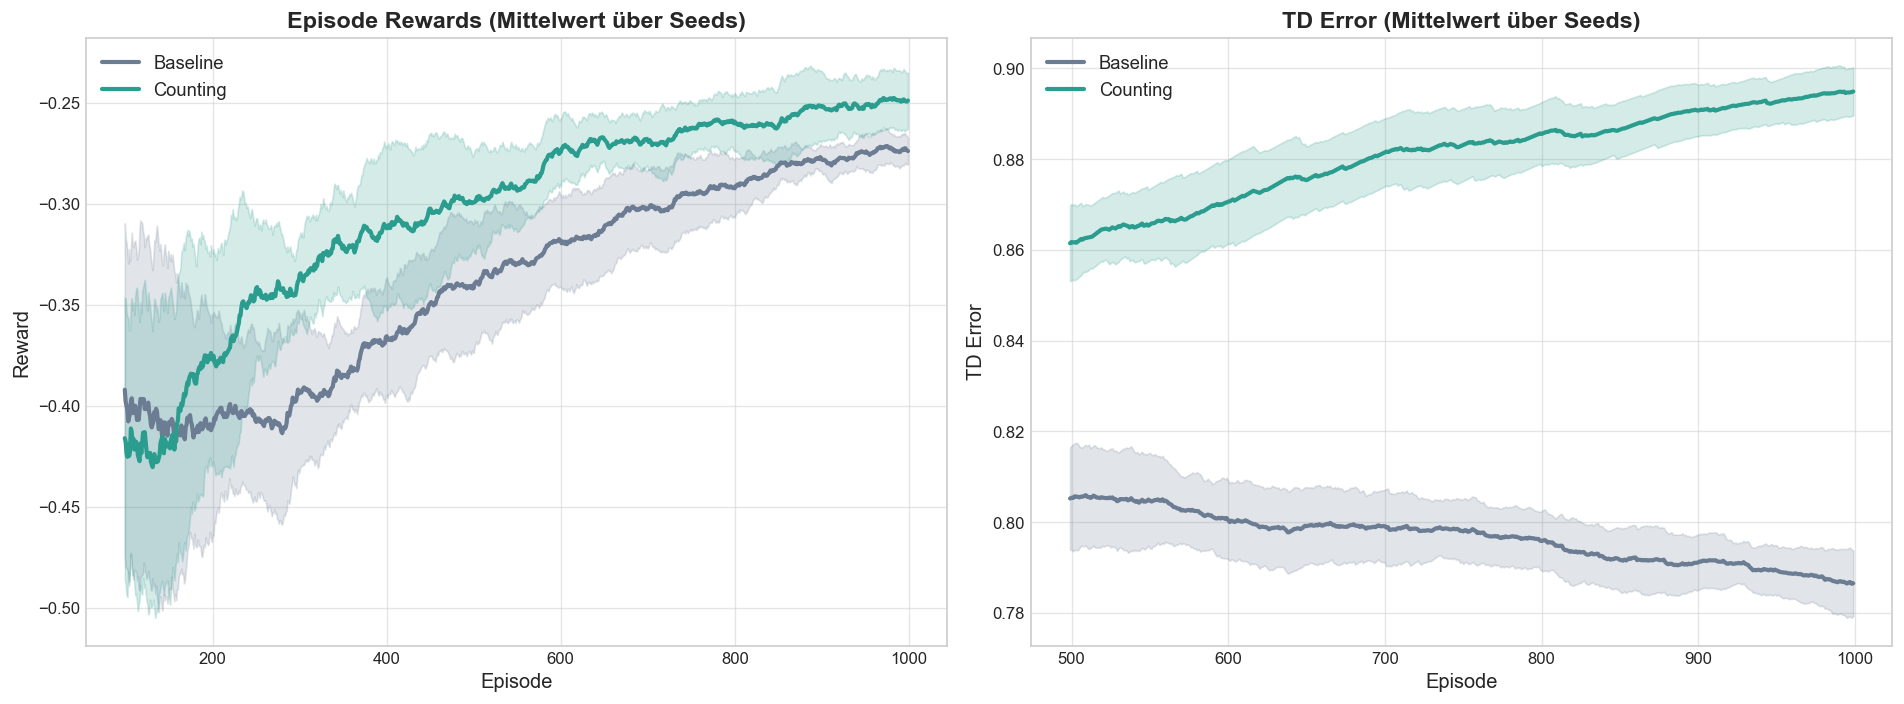

In [19]:
plot_all(agents, reward_window=1000, td_window=5000)

## Performance Comparison

In [20]:
print("Starte finale Evaluierung der Agenten...\n")

def get_reward_matrix(agent_list):
    return np.vstack([
        np.asarray(agent.episode_rewards)
        for seed, agent in agent_list
    ])


def flatten_rewards(agent_list):
    return get_reward_matrix(agent_list).ravel()


def calculate_metrics(rewards: np.ndarray) -> dict:

    rewards = np.asarray(rewards)

    wins = np.sum(rewards == 1)
    losses = np.sum(rewards == -1)
    draws = np.sum(rewards == 0)
    total = len(rewards)

    return {
        "win_rate": wins / total if total > 0 else 0.0,
        "loss_rate": losses / total if total > 0 else 0.0,
        "draw_rate": draws / total if total > 0 else 0.0,
        "average_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
    }


grouped = group_agents_by_type(agents)

# Flatten für Gesamtvergleich (gut für Reporting)
baseline_rewards = flatten_rewards(grouped["baseline"])
counting_rewards = flatten_rewards(grouped["counting"])

baseline_metrics = calculate_metrics(baseline_rewards)
counting_metrics = calculate_metrics(counting_rewards)

# Ausgabe
for name, metrics in [
    ("Baseline", baseline_metrics),
    ("Counting", counting_metrics)
]:
    print(f"{name} metrics:")
    print(f"  Win Rate:       {metrics['win_rate']:.1%}")
    print(f"  Loss Rate:      {metrics['loss_rate']:.1%}")
    print(f"  Draw Rate:      {metrics['draw_rate']:.1%}")
    print(f"  Avg Reward:     {metrics['average_reward']:.3f}")
    print(f"  Std Reward:     {metrics['std_reward']:.3f}")
    print()

Starte finale Evaluierung der Agenten...

Baseline metrics:
  Win Rate:       32.9%
  Loss Rate:      60.3%
  Draw Rate:      6.7%
  Avg Reward:     -0.274
  Std Reward:     0.926

Counting metrics:
  Win Rate:       35.2%
  Loss Rate:      60.1%
  Draw Rate:      4.7%
  Avg Reward:     -0.249
  Std Reward:     0.944



Figure saved: E:\tomni\Documents\01_Code\ml-blackjack\images\final_evaluation_metrics.png


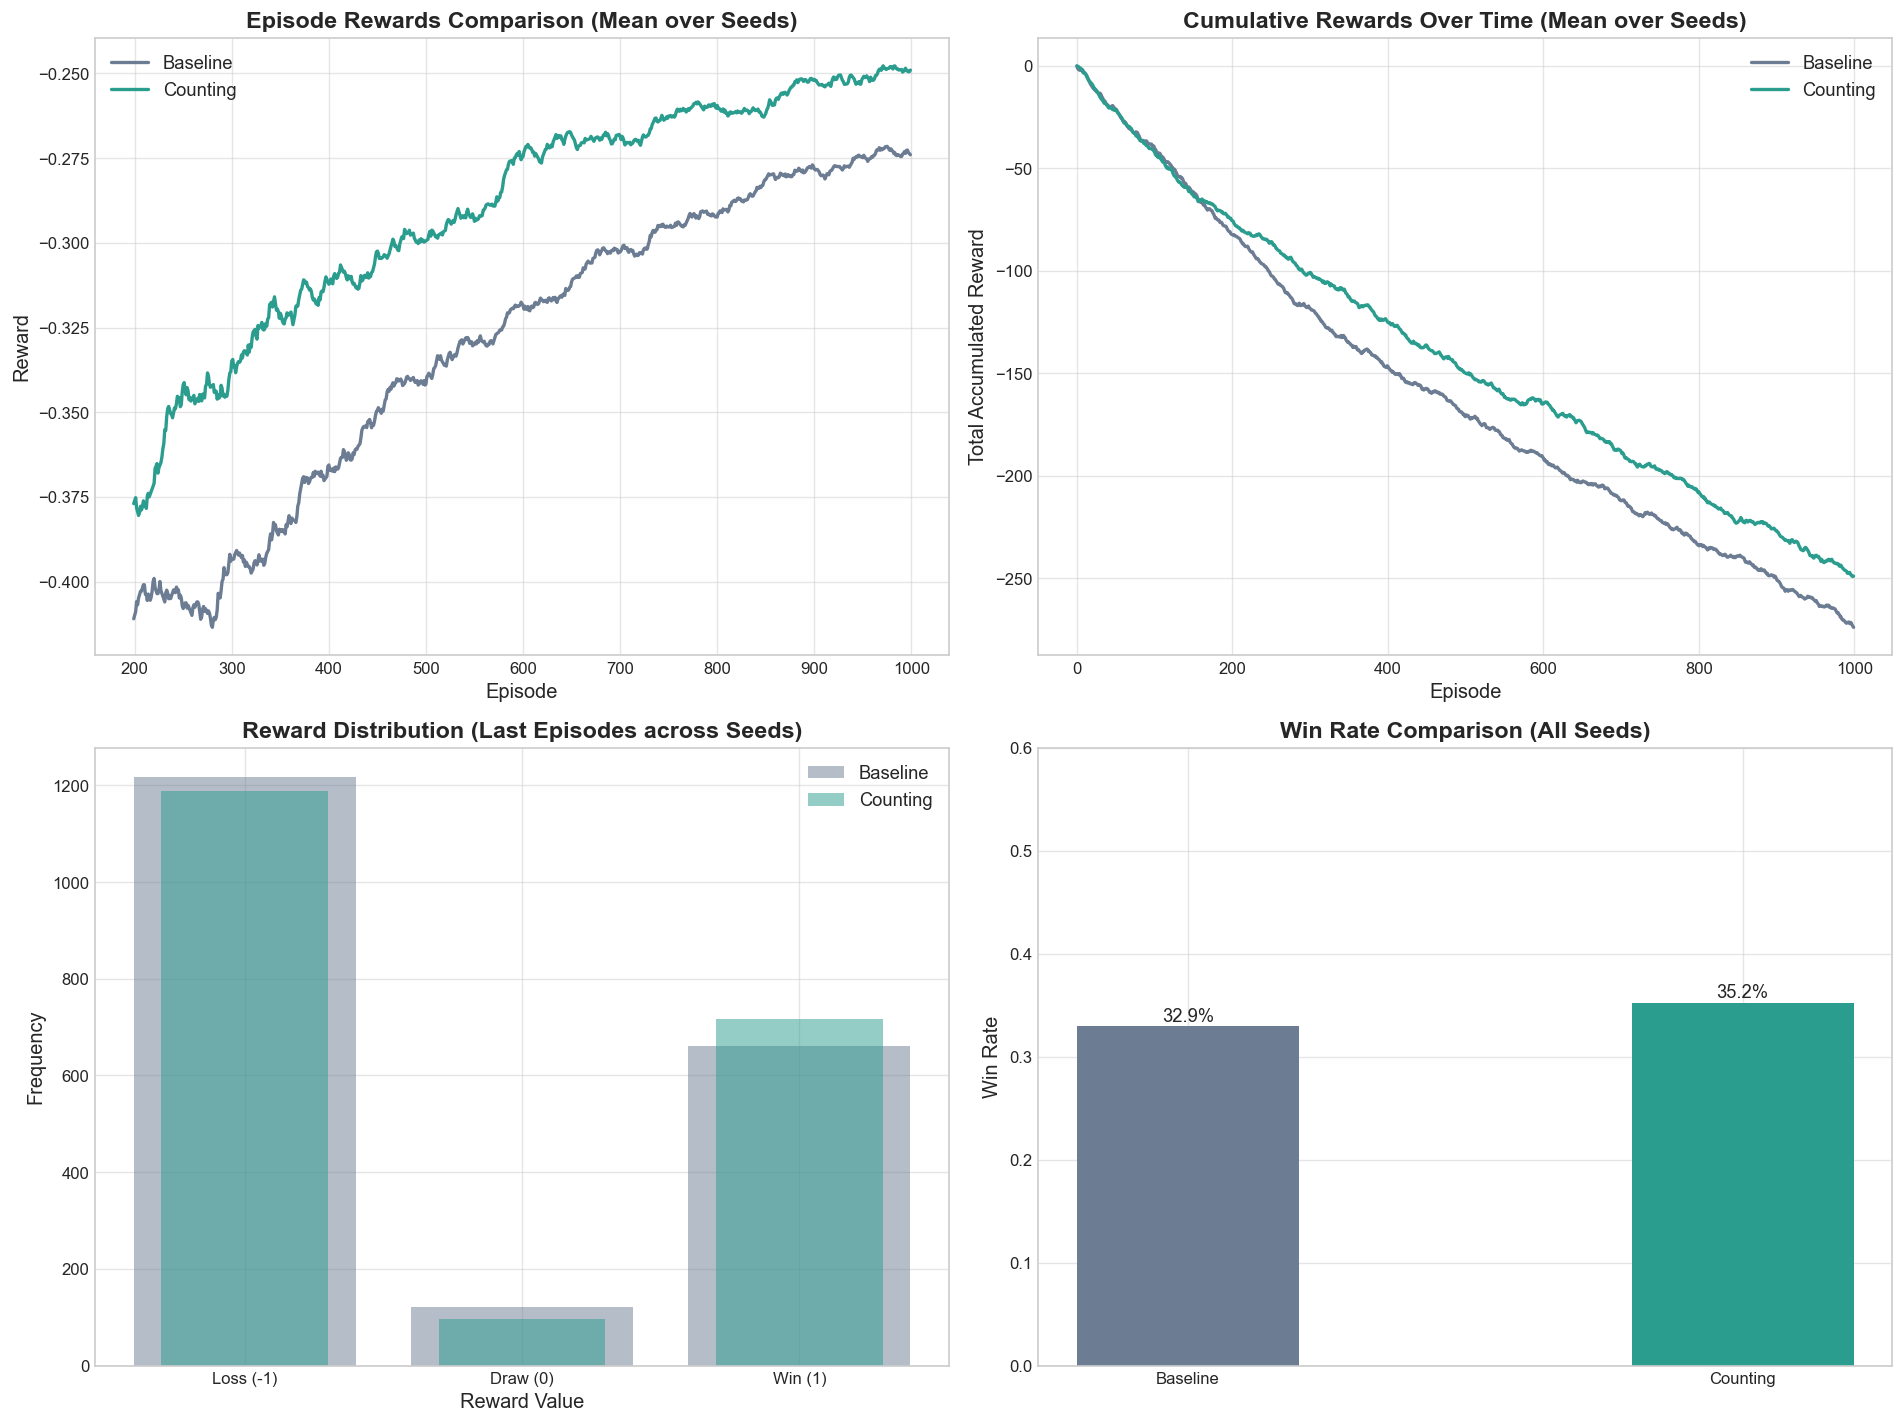

In [21]:
# Fenstergröße für die statistische Glättung
SMOOTH_WINDOW = 2000

fig, axs = plt.subplots(2, 2, figsize=(16, 12))


# =========================
# Top-Left: Smoothed Reward (Mean über Seeds)
# =========================

b_matrix = get_reward_matrix(grouped["baseline"])
c_matrix = get_reward_matrix(grouped["counting"])

b_mean = b_matrix.mean(axis=0)
c_mean = c_matrix.mean(axis=0)

r_mean_b, _, x_r_b = get_moving_stats(b_mean, SMOOTH_WINDOW)
r_mean_c, _, x_r_c = get_moving_stats(c_mean, SMOOTH_WINDOW)

axs[0, 0].plot(x_r_b, r_mean_b, label="Baseline", color="#6b7c93")
axs[0, 0].plot(x_r_c, r_mean_c, label="Counting",  color="#2a9d8f")

axs[0, 0].set_title("Episode Rewards Comparison (Mean over Seeds)")
axs[0, 0].set_xlabel("Episode")
axs[0, 0].set_ylabel("Reward")
axs[0, 0].legend()


# =========================
# Top-Right: Cumulative Reward (Mean curve)
# =========================

axs[0, 1].plot(np.cumsum(b_mean), label="Baseline", color="#6b7c93")
axs[0, 1].plot(np.cumsum(c_mean), label="Counting",  color="#2a9d8f")

axs[0, 1].set_title("Cumulative Rewards Over Time (Mean over Seeds)")
axs[0, 1].set_xlabel("Episode")
axs[0, 1].set_ylabel("Total Accumulated Reward")
axs[0, 1].legend()


# =========================
# Bottom-Left: Reward Distribution (all seeds flattened)
# =========================

bins = [-1.5, -0.5, 0.5, 1.5]

EVAL_WINDOW = 2000

baseline_flat = flatten_rewards(grouped["baseline"])
counting_flat = flatten_rewards(grouped["counting"])

axs[1, 0].hist(
    baseline_flat[-EVAL_WINDOW:],
    alpha=0.5,
    label="Baseline",
    color="#6b7c93",
    bins=bins,
    rwidth=0.8
)

axs[1, 0].hist(
    counting_flat[-EVAL_WINDOW:],
    alpha=0.5,
    label="Counting",
    color="#2a9d8f",
    bins=bins,
    rwidth=0.6
)

axs[1, 0].set_title(f"Reward Distribution (Last Episodes across Seeds)")
axs[1, 0].set_xlabel("Reward Value")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].set_xticks([-1, 0, 1])
axs[1, 0].set_xticklabels(["Loss (-1)", "Draw (0)", "Win (1)"])
axs[1, 0].legend()


# =========================
# Bottom-Right: Win Rate Comparison
# =========================

win_rates = [
    baseline_metrics["win_rate"],
    counting_metrics["win_rate"]
]

names = ["Baseline", "Counting"]

axs[1, 1].bar(
    names,
    win_rates,
    color=["#6b7c93", "#2a9d8f"],
    width=0.4
)

axs[1, 1].set_title("Win Rate Comparison (All Seeds)")
axs[1, 1].set_ylabel("Win Rate")
axs[1, 1].set_ylim(0, 0.6)

for i, v in enumerate(win_rates):
    axs[1, 1].text(i, v + 0.005, f"{v:.1%}", ha="center")


save_fig("final_evaluation_metrics")
plt.show()